In [1]:
import pandas as pd
import numpy as nm

In [2]:
df=pd.read_csv('Fraud_Analysis_Dataset.csv')

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11142 entries, 0 to 11141
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            11142 non-null  int64  
 1   type            11142 non-null  object 
 2   amount          11142 non-null  float64
 3   nameOrig        11142 non-null  object 
 4   oldbalanceOrg   11142 non-null  float64
 5   newbalanceOrig  11142 non-null  float64
 6   nameDest        11142 non-null  object 
 7   oldbalanceDest  11142 non-null  float64
 8   newbalanceDest  11142 non-null  float64
 9   isFraud         11142 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 870.6+ KB


In [5]:
df.shape

(11142, 10)

In [6]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

In [7]:
import matplotlib.pyplot as plt

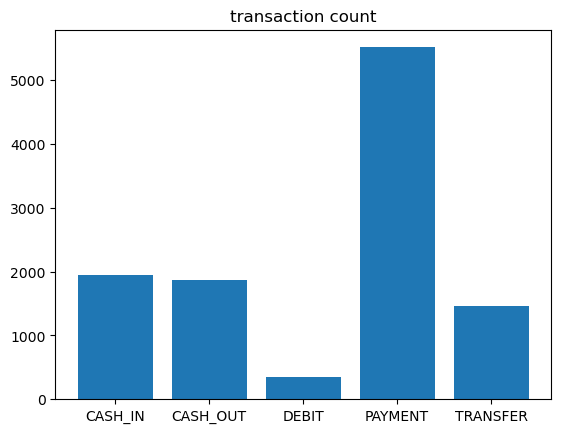

In [8]:
import seaborn as sns
type_tr=df['type'].value_counts().sort_index()
plt.bar(type_tr.index,type_tr.values,label=True)
plt.title('transaction count')
plt.show()

In [9]:
fraud_count=df[df['isFraud']==1]['type'].value_counts()
fraud_count

type
CASH_OUT    578
TRANSFER    564
Name: count, dtype: int64

In [10]:
df[df['isFraud']==1]['type'].value_counts()

type
CASH_OUT    578
TRANSFER    564
Name: count, dtype: int64

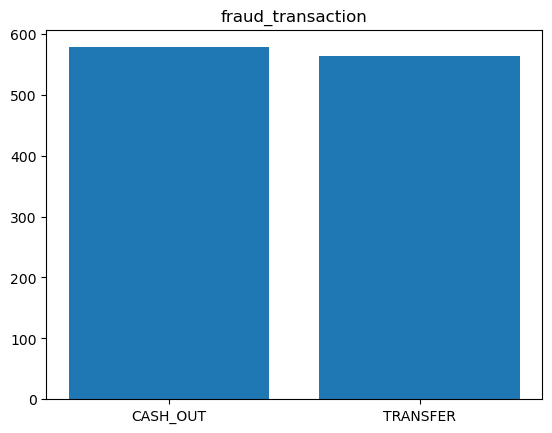

In [11]:
plt.bar(x=fraud_count.index,height=fraud_count.values)
plt.title('fraud_transaction')
plt.show()

In [12]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1


In [13]:
#df=pd.get_dummies(df,axis=1,dtype='int')
x=df.drop(['step','nameOrig','nameDest','step','isFraud'],axis=1)
y=df['isFraud']

In [14]:
x.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
0,TRANSFER,181.0,181.0,0.0,0.0,0.0
1,CASH_OUT,181.0,181.0,0.0,21182.0,0.0
2,TRANSFER,2806.0,2806.0,0.0,0.0,0.0
3,CASH_OUT,2806.0,2806.0,0.0,26202.0,0.0
4,TRANSFER,20128.0,20128.0,0.0,0.0,0.0


In [15]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: isFraud, dtype: int64

In [16]:
df=pd.get_dummies(data=x,dtype='int',drop_first=True)
df.head()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,181.0,181.0,0.0,0.0,0.0,0,0,0,1
1,181.0,181.0,0.0,21182.0,0.0,1,0,0,0
2,2806.0,2806.0,0.0,0.0,0.0,0,0,0,1
3,2806.0,2806.0,0.0,26202.0,0.0,1,0,0,0
4,20128.0,20128.0,0.0,0.0,0.0,0,0,0,1


In [17]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [18]:
x_scale=scaler.fit_transform(df)
x_scale

array([[-0.28026556, -0.43115999, -0.39475428, ..., -0.17902209,
        -0.98910974,  2.57111955],
       [-0.28026556, -0.43115999, -0.39475428, ..., -0.17902209,
        -0.98910974, -0.38893563],
       [-0.27681175, -0.42993502, -0.39475428, ..., -0.17902209,
        -0.98910974,  2.57111955],
       ...,
       [ 0.27626264, -0.37156334, -0.39475428, ..., -0.17902209,
        -0.98910974, -0.38893563],
       [-0.27906425, -0.42474954, -0.38861782, ..., -0.17902209,
         1.01101017, -0.38893563],
       [-0.26835212, -0.4125955 , -0.38005076, ..., -0.17902209,
         1.01101017, -0.38893563]])

In [19]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_scale,y,test_size=0.2,random_state=70)

In [23]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.model_selection import cross_val_score
for i in range(1,10):
    model_cv=DecisionTreeClassifier(max_depth=i,random_state=42)
    score=cross_val_score(model_cv,x_train,y_train,cv=5)
    print(f'cv={i},the values is{nm.mean(score)}')

cv=1,the values is0.9154047485511312
cv=2,the values is0.9339172871608842
cv=3,the values is0.961517209862695
cv=4,the values is0.9662299444875627
cv=5,the values is0.977000389638266
cv=6,the values is0.9858636215712305
cv=7,the values is0.9908001936231512
cv=8,the values is0.9910247234606929
cv=9,the values is0.992595173395323


In [28]:
mt=DecisionTreeClassifier(random_state=42)
path=mt.cost_complexity_pruning_path(x_train,y_train)
ccp_alphas=path.ccp_alphas
for alpha in ccp_alphas:
    dt_pruning=DecisionTreeClassifier(random_state=42,ccp_alpha=alpha)
    score=cross_val_score(dt_pruning,x_train,y_train,cv=6)
    print(f'phas={alpha} in the score={nm.mean(score)}')

phas=0.0 in the score=0.9915857392528545
phas=0.00010559592399733373 in the score=0.9915857392528545
phas=0.00010709586609956861 in the score=0.9915857392528545
phas=0.00010845581360559478 in the score=0.9915857392528545
phas=0.00010868955458319309 in the score=0.9915857392528545
phas=0.00010889579662225035 in the score=0.9915857392528545
phas=0.00010964576767336778 in the score=0.9915857392528545
phas=0.00011079322338157735 in the score=0.9915857392528545
phas=0.0001108910684419676 in the score=0.9915857392528545
phas=0.0001113457020559003 in the score=0.9915857392528545
phas=0.00011157580367121598 in the score=0.9915857392528545
phas=0.00011178768499535893 in the score=0.9915857392528545
phas=0.00011184173969118146 in the score=0.9915857392528545
phas=0.00011193036189020016 in the score=0.9915857392528545
phas=0.00011200607336982687 in the score=0.9915857392528545
phas=0.00013463480309660046 in the score=0.9929319363819139
phas=0.0001474571652962768 in the score=0.9929319363819139
ph

In [30]:
for depth in range(1, 15):  # trying depths 1 to 14
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(x_train, y_train)
    
    train_acc = model.score(x_train, y_train)
    test_acc = model.score(x_test, y_test)
    
    #train_scores.append(train_acc)
    #test_scores.append(test_acc)
    print(f"Depth={depth}, Train={train_acc:.2f}, Test={test_acc:.2f}")

Depth=1, Train=0.92, Test=0.92
Depth=2, Train=0.93, Test=0.93
Depth=3, Train=0.96, Test=0.96
Depth=4, Train=0.97, Test=0.97
Depth=5, Train=0.98, Test=0.98
Depth=6, Train=0.99, Test=0.99
Depth=7, Train=1.00, Test=0.99
Depth=8, Train=1.00, Test=0.99
Depth=9, Train=1.00, Test=0.99
Depth=10, Train=1.00, Test=0.99
Depth=11, Train=1.00, Test=0.99
Depth=12, Train=1.00, Test=0.99
Depth=13, Train=1.00, Test=0.99
Depth=14, Train=1.00, Test=0.99


In [86]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
model=DecisionTreeClassifier(max_depth=6,min_samples_split=2,random_state=60,criterion='entropy',class_weight='balanced')

In [87]:
# for c in [0.01,0.1,10,100]:
#     model=LogisticRegression(C=c,max_iter=1000)
#     model.fit(x_train,y_train)
#     print(f'C={c}, train_accuracy={accuracy_score(y_train,model.predict(x_train)):.3f}, test_accuracy={accuracy_score(y_test,model.predict(x_test)):.3f}')

In [88]:
model.fit(x_train,y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=5, random_state=60)

In [105]:
from imblearn.over_sampling import SMOTE
sm=SMOTE(random_state=42)

In [109]:
x_train_sm,y_train_sm=sm.fit_resample(x_train,y_train)

In [110]:
model.fit(x_train_sm,y_train_sm)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=5, random_state=60)

In [111]:
y_pred_tt=model.predict(x_test)

In [112]:
y_pred_tr=model.predict(x_train)

In [113]:
from sklearn.metrics import classification_report,accuracy_score,precision_score,recall_score,confusion_matrix,roc_auc_score

In [114]:
test_acc=accuracy_score(y_test,y_pred_tt)
train_acc=accuracy_score(y_train,y_pred_tr)
print('test:',test_acc)
print('train:',train_acc)

test: 0.9762225213100045
train: 0.9800291708740043


In [115]:
x.columns

Index(['type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest'],
      dtype='object')

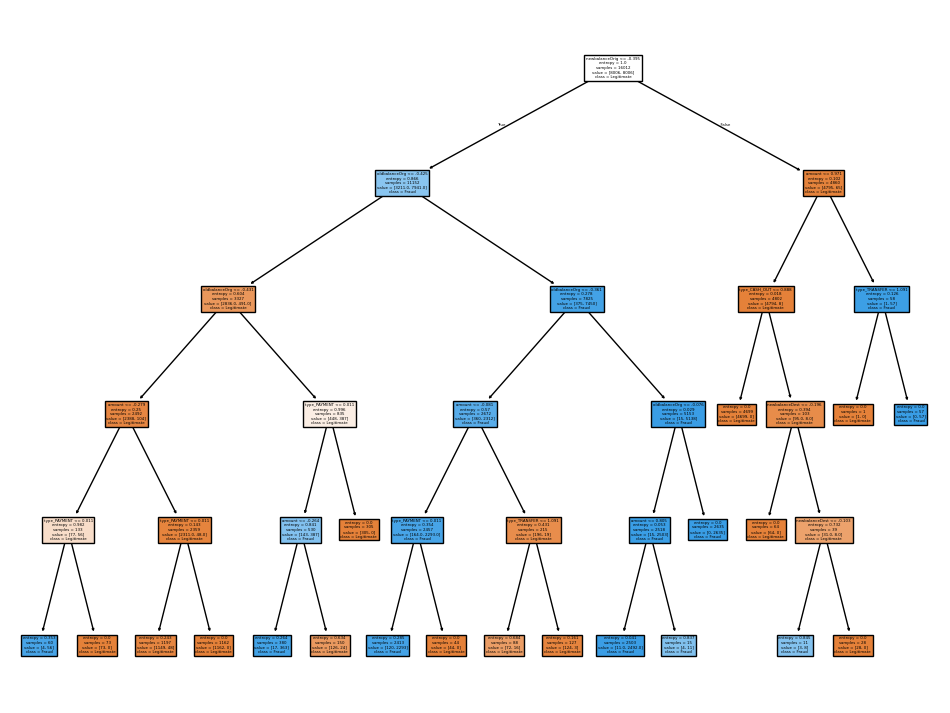

In [116]:
feature_names = df.columns

plt.figure(figsize=(12,9))
plot_tree(model, feature_names=feature_names, class_names=['Legitimate', 'Fraud'], filled=True)
plt.show()


In [117]:
print(model.n_features_in_)
print(x_train.shape)

9
(8913, 9)


In [118]:
print(model.n_features_in_)

9


In [119]:
con=classification_report(y_test,y_pred_tt)
print('test')
print(con)
con_tr=classification_report(y_train,y_pred_tr)
print('train')
print(con_tr)

test
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1994
           1       0.83      0.97      0.90       235

    accuracy                           0.98      2229
   macro avg       0.91      0.98      0.94      2229
weighted avg       0.98      0.98      0.98      2229

train
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      8006
           1       0.85      0.98      0.91       907

    accuracy                           0.98      8913
   macro avg       0.92      0.98      0.95      8913
weighted avg       0.98      0.98      0.98      8913



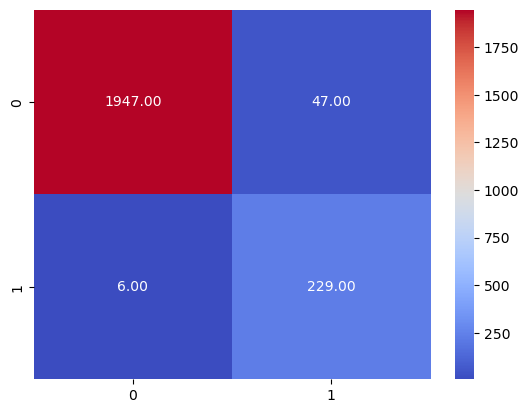

In [123]:
import seaborn as sns
cm=confusion_matrix(y_test,y_pred_tt)
sns.heatmap(cm,annot=True,cmap='coolwarm',fmt='.2f')
plt.show()